# Portfolio Design 01 — Probabilistic Regime Engine

## TL;DR

- The $1,000,000 systematic long/short mandate is encoded in configuration with a five-session maximum holding period, 10% volatility target, 2× gross cap, ±25% net range, risk-contribution limits, drawdown controls, and a minimum one-minute execution delay.
- The regime engine produces **596 complete observable probability rows** from development data only.
- Walk-forward Markov probabilities are available on **226 validation dates** across four expanding folds; they are never allowed more than 25% ensemble weight.
- Dominant observable/ensemble classifications in the available development sample: low volatility trend 300, stress transition 180, mean reverting choppy 71, high volatility trend 45.
- Probabilities and confidence are research state variables, not trading signals. No P&L, parameter optimization, or holdout access occurs here.


## Context & Methods

The first portfolio-design component is a causal regime ensemble. Observable measures supply the primary evidence; a four-state Markov-switching model provides a smaller, independently estimated component.

### Key Assumptions

- All inputs are point-in-time, development-only, and based on information known at the session close.
- A position based on these states may execute no earlier than one minute later.
- Markov models are fitted only on each fold's training sample, then filtered—not smoothed—through validation observations with fixed parameters.
- Markov state identities are mapped from fitted means and variances; that mapping is model-dependent and therefore confidence-weighted.
- Uncertain classifications reduce regime reliance rather than forcing a hard state.


In [1]:
from pathlib import Path
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists(): ROOT = ROOT.parent
regimes = pd.read_parquet(ROOT / "data/processed/regimes/development_regime_probabilities.parquet")
folds = pd.read_csv(ROOT / "data/catalog/development_walk_forward_folds.csv")
mandate = yaml.safe_load((ROOT / "config/portfolio.yaml").read_text())["portfolio_design"]
regimes["trading_date"] = pd.to_datetime(regimes["trading_date"])
ensemble_columns = [
    "ensemble_low_volatility_trend", "ensemble_high_volatility_trend",
    "ensemble_mean_reverting_choppy", "ensemble_stress_transition",
]
valid = regimes[ensemble_columns].notna().all(axis=1)
assert regimes.loc[valid, ensemble_columns].sum(axis=1).between(.999999, 1.000001).all()
print(f"Complete regime rows: {valid.sum():,}; Markov validation rows: {regimes['markov_available'].sum():,}")

Complete regime rows: 596; Markov validation rows: 226


## The mandate is explicit and machine-readable

In [2]:
pd.json_normalize(mandate, sep=".").T.rename(columns={0: "configured_value"})

,configured_value
status,design_only_no_holdout_no_backtest
starting_capital_usd,1000000
data_frequency,1_minute_ohlcv
style,systematic_long_short
maximum_holding_sessions,5
build_sequence,"[regime_engine, continuously_invested_trend_ba..."
continuously_invested.enabled,True
continuously_invested.definition,maintain_long_and_short_gross_exposure_not_eve...
continuously_invested.emergency_deleveraging_allowed,True
universe.initial,"[CL, HG, NQ, ZN, ZT]"


## Observable states combine trend, volatility, range, correlation, and liquidity

The observable engine uses ATR and realized-volatility state, volatility acceleration, trend efficiency, moving-average structure, range expansion, return autocorrelation, cross-market correlation concentration, and minute-bar activity proxies. These measures are converted to soft probabilities, not hard trading labels.


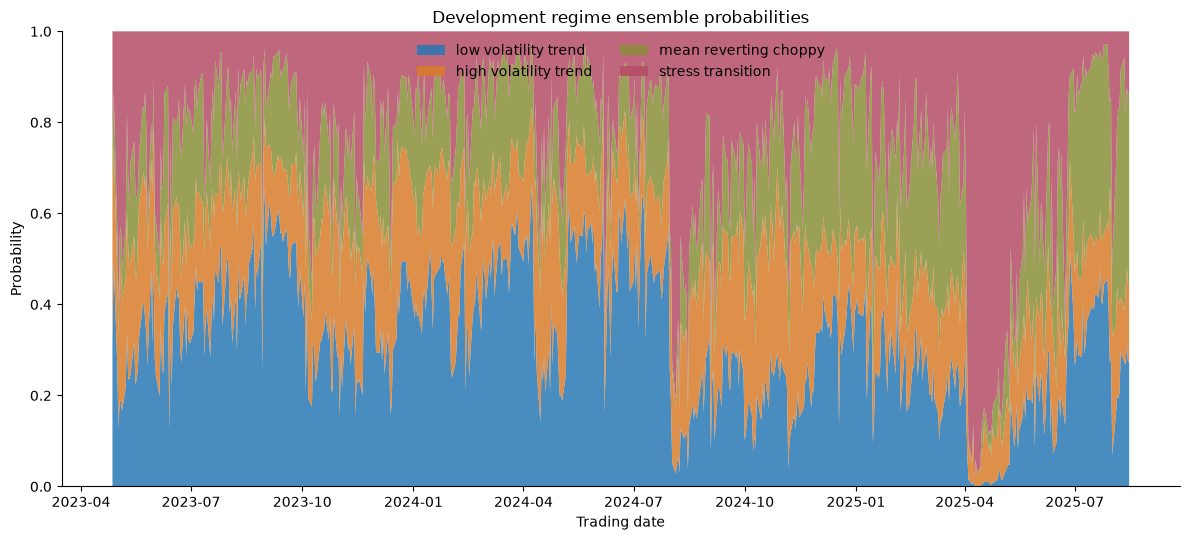

In [3]:
plot_data = regimes.loc[valid, ["trading_date", *ensemble_columns]].set_index("trading_date")
plot_data.columns = [column.removeprefix("ensemble_").replace("_", " ") for column in plot_data]
colors = ["#2878B5", "#D97B29", "#8A8F3A", "#B44C65"]
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(plot_data.index, plot_data.T, labels=plot_data.columns, colors=colors, alpha=.85)
ax.set(title="Development regime ensemble probabilities", xlabel="Trading date", ylabel="Probability", ylim=(0, 1))
ax.legend(loc="upper center", ncol=2, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

## Confidence controls how much the regime engine may influence allocation

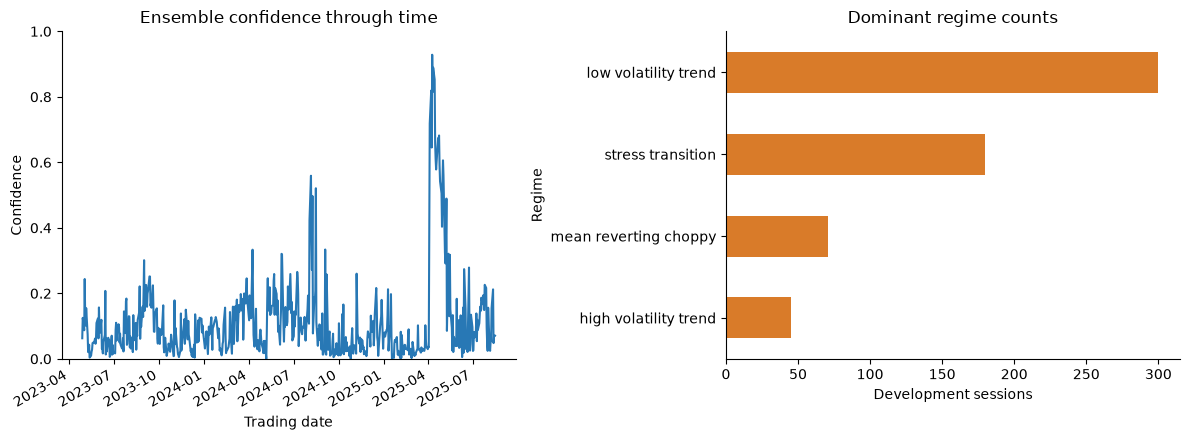

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
regimes.loc[valid].plot(x="trading_date", y="ensemble_confidence", ax=axes[0], color="#2878B5", legend=False)
axes[0].set(title="Ensemble confidence through time", xlabel="Trading date", ylabel="Confidence", ylim=(0, 1))
dominant = regimes.loc[valid, ensemble_columns].idxmax(axis=1).str.removeprefix("ensemble_").str.replace("_", " ")
dominant.value_counts().sort_values().plot.barh(ax=axes[1], color="#D97B29")
axes[1].set(title="Dominant regime counts", xlabel="Development sessions", ylabel="Regime")
for ax in axes: ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.show()

## Markov probabilities are genuinely walk-forward

In [5]:
folds

,fold,train_start,train_end,embargo_start,embargo_end,validation_start,validation_end,train_sessions,validation_sessions
0,1,2022-10-12,2024-09-23,2024-09-24,2024-09-30,2024-10-01,2024-12-27,504,63
1,2,2022-10-12,2024-12-19,2024-12-20,2024-12-27,2024-12-30,2025-03-27,567,63
2,3,2022-10-12,2025-03-20,2025-03-21,2025-03-27,2025-03-28,2025-06-25,630,63
3,4,2022-10-12,2025-06-18,2025-06-19,2025-06-25,2025-06-26,2025-08-15,693,37


In [6]:
markov_coverage = regimes.loc[regimes["markov_available"]].groupby("fold").agg(
    validation_rows=("trading_date", "size"),
    mean_confidence=("markov_confidence", "mean"),
)
markov_coverage

,validation_rows,mean_confidence
fold,,
1.0,63,0.530382
2.0,63,0.539716
3.0,63,0.660340
4.0,37,0.901962


The Markov model is trained separately in each expanding fold. Validation probabilities are filtered with fixed training parameters; future validation observations do not revise earlier probabilities. The ensemble gives this component 25% weight only when it is available.


## Limitations and controls

- State labels summarize fitted distributional behavior; they are not economic truths.
- The Markov model is univariate and cannot independently establish causality or tradability.
- Observable scores are intentionally transparent but still require development-fold sensitivity testing before they affect risk.
- Correlation concentration can rise for benign or adverse reasons and must be interpreted with volatility and liquidity.
- Continuation-series methodology, transaction costs, roll costs, and liquidity limits remain unresolved P&L gates.
- No regime-conditioned strategy result is calculated in this notebook.


## Next build

The next separate notebook will define the continuously invested trend baseline: signed forecasts, one-minute execution lag, volatility/covariance sizing, gross and net exposure controls, and drawdown overlays. Its development-fold results will remain isolated from future reversal, relative-value, and lead/lag sleeves so each contribution can be audited.
